In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [171]:
df=pd.read_csv("Website.csv")

In [172]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   # ----------------------------------------  3183 non-null   object
 1   Unnamed: 1                                  3183 non-null   object
 2   Unnamed: 2                                  3183 non-null   object
 3   Unnamed: 3                                  3183 non-null   object
 4   Unnamed: 4                                  3183 non-null   object
 5   Unnamed: 5                                  3183 non-null   object
 6   Unnamed: 6                                  3183 non-null   object
 7   Unnamed: 7                                  3183 non-null   object
 8   Unnamed: 8                                  3183 non-null   object
 9   Unnamed: 9                                  3183 non-null   object
dtypes: object(10)
memory usa

**Here the column name is not accuate also the datatype of the column is also not accurate.**

# Assigning the appropriate column name.

In [174]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns=["channel group","Date-hour", "Users","Sessions","Engaged_sessions",	"Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]

In [175]:
df.head()

,channel group,Date-hour,Users,Sessions,Engaged_sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


**Here we assign 0th row as the columes and reset the index position.**

# Assigning the appropriate column Datatype.

In [176]:
df["Date-hour"]=pd.to_datetime(df["Date-hour"],format="%Y%M%d%H")

In [177]:
numeric_column=df.columns.drop(["channel group","Date-hour"])
df[numeric_column]=df[numeric_column].apply(pd.to_numeric)

In [178]:
df["Hour"]=df["Date-hour"].dt.hour

**Here we created new column "hour" by the help of "Date-hour" column .**

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   Date-hour                            3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged_sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [180]:
df.describe()

,Date-hour,Users,Sessions,Engaged_sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-01-16 19:30:57.548711680,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-01-01 00:05:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-01-10 02:04:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-01-17 01:04:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-01-24 00:04:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-01-30 23:04:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


In [181]:
df.isnull().sum()

channel group                          0
Date-hour                              0
Users                                  0
Sessions                               0
Engaged_sessions                       0
Average engagement time per session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
Hour                                   0
dtype: int64

In [151]:
df.duplicated().sum()

np.int64(0)

**Now, the data is cleaned and ready for visualization.**

# 1] The session and user over time .

In [182]:
sns.set(style="darkgrid")

In [183]:
combine=df.groupby("Hour")[["Users","Sessions"]].sum()
combine.head(10)

,Users,Sessions
Hour,,
0,5864,8148
1,4011,5228
2,3167,3999
3,2531,3199
4,2234,2786
5,2093,2598
6,2551,3161
7,3176,3946
8,3855,4781


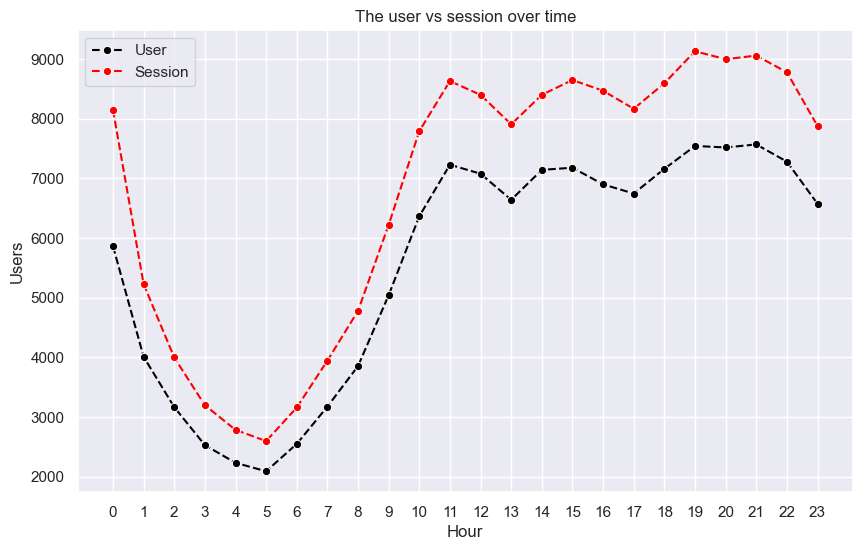

In [184]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Hour",y="Users",data=combine,label="User",linestyle='--',color="black",marker="o")
sns.lineplot(x="Hour",y="Sessions",data=combine,label="Session",linestyle='--',color='red',marker="o")
plt.title("The user vs session over time")
plt.xticks(range(24))
plt.show()     

# Insights from Users vs Sessions by Hour Analysis

1. **Early Morning:** Both users and sessions decrease until around hour 5.

2. **Morning Growth:** Traffic rises sharply from around hour 6 to hour 11.

3. **Afternoon:** Traffic fluctuates but remains relatively high.

4. **Evening Peak:** Both metrics reach their highest levels around hours 19–21.

5. **Sessions Exceed Users:** The red line stays above the black line throughout the displayed hours.



# 2] which channel bought the highest users on the website.

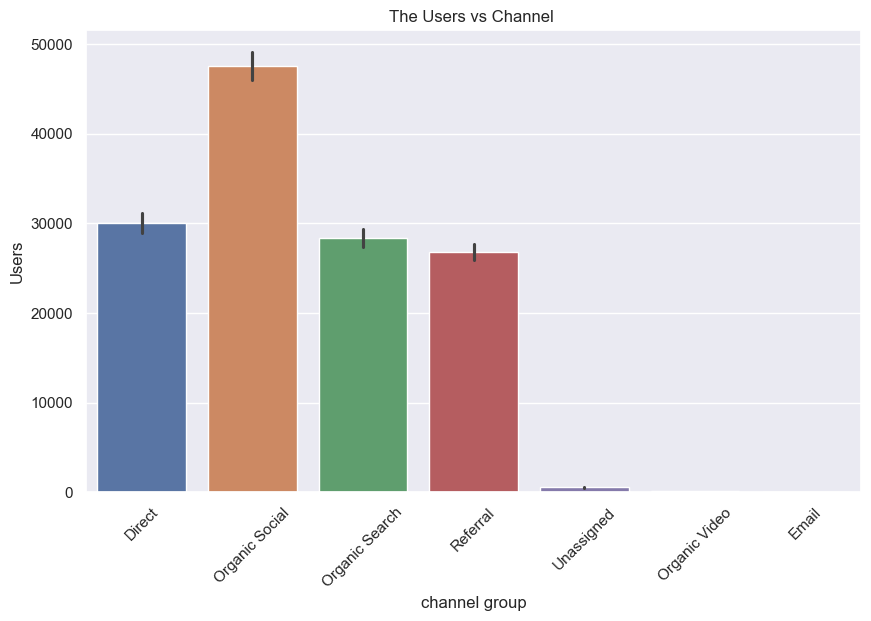

In [185]:
plt.figure(figsize=(10,6))
sns.barplot(x="channel group",y="Users",data=df,estimator=np.sum,palette="deep")
plt.title("The Users vs Channel ")
plt.xticks(rotation=45)
plt.show()

**The channel [Organic Social] bought the highest user on the website** 

# 3] Average engagement of user by channnel

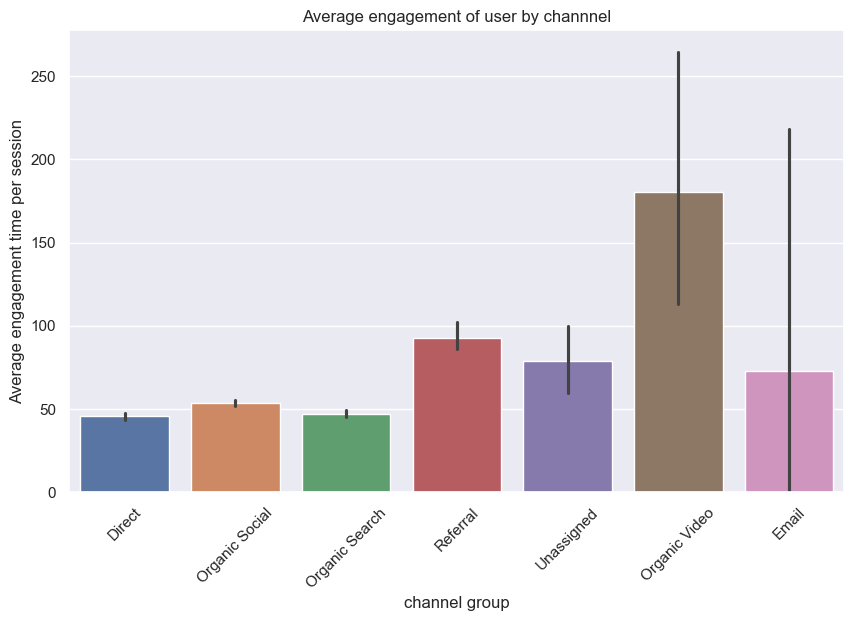

In [186]:
plt.figure(figsize=(10,6))
sns.set(style="darkgrid")
sns.barplot(data=df,x="channel group",y="Average engagement time per session",palette="deep")
plt.title("Average engagement of user by channnel")
plt.xticks(rotation=45)
plt.show()

## Insights from Channel Engagement

1. **Organic Search:** The Organic Search channel has the highest average time spent by users on the website, indicating strong user engagement.

2. **Email and Referral:** Email and Referral channels also show high user engagement. The company should focus on optimizing these channels to further improve user engagement and website performance.

# 4]Engagement rate according to the channel.

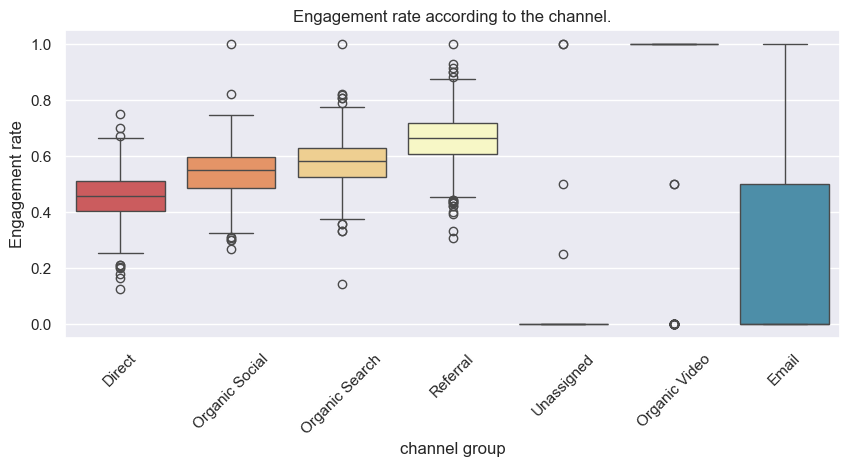

In [187]:
plt.figure(figsize=(10,4))
sns.set(style="darkgrid")
sns.boxplot(data=df,x="channel group",y="Engagement rate",palette="Spectral")
plt.title("Engagement rate according to the channel.")
plt.xticks(rotation=45)
plt.show()

## Insights from Engagement Rate by Channel

1. **Referral:** The Referral channel has a relatively high median engagement rate compared with most channels.

2. **Organic Search:** Organic Search shows a moderate-to-high engagement rate, with some outliers indicating unusually high or low values.

3. **Direct:** The Direct channel has a lower median engagement rate than Referral and Organic Search.

4. **Organic Social:** Organic Social shows a moderate engagement rate, with some high-engagement outliers.

5. **Email and Unassigned:** These channels show wide or unusual distributions, suggesting that the engagement data may be inconsistent or that the number of observations may be limited. Further investigation is needed.

# 5] Channel driving more engaged session compared to non-engaged ones.

In [188]:
df["non_Engaged_sessions"]=df["Sessions"]-df["Engaged_sessions"]

**Here we creted the new colummn "non_Engaged_sessions" .**

In [195]:
# Calculate sessions by channel
channel_sessions = df.groupby("channel group")[
    ["Engaged_sessions", "non_Engaged_sessions"]
].sum().reset_index()

# Convert to long format for grouped bars
channel_sessions = channel_sessions.melt(
    id_vars="channel group",
    value_vars=["Engaged_sessions", "non_Engaged_sessions"],
    var_name="variable",
    value_name="Sessions"
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=channel_sessions,
    x="channel_group",
    y="Sessions",
    hue="variable",
    palette=["royalblue", "darkorange"]
)

ValueError: Could not interpret value `channel_group` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [161]:
df

,channel group,Date-hour,Users,Sessions,Engaged_sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-01-16 23:04:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-01-17 19:04:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-01-17 23:04:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-01-17 18:04:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-01-17 20:04:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
...,...,...,...,...,...,...,...,...,...,...,...
3177,Unassigned,2024-01-28 06:04:00,0,1,0,0.000000,0.000000,2.000000,0.000000,2,6
3178,Unassigned,2024-01-30 05:04:00,0,1,0,0.000000,0.000000,2.000000,0.000000,2,5
3179,Unassigned,2024-01-30 06:04:00,0,1,0,0.000000,0.000000,2.000000,0.000000,2,6
3180,Unassigned,2024-01-01 05:05:00,0,1,0,0.000000,0.000000,2.000000,0.000000,2,5
